### Introdução CudaPy
---

> __NumPy__ é uma biblioteca em Python que fornece operações eficientes para manipulação de arrays e matrizes usando a CPU. Embora o NumPy seja rápido para muitas operações, ele se torna menos eficiente à medida que o volume de dados aumenta significativamente ou quando o problema pode se beneficiar de paralelismo massivo.

> __CuPy__ é uma biblioteca projetada para operações numéricas usando GPU. As GPUs são projetadas para processamento paralelo massivo, o que as torna altamente eficientes para computações que podem ser divididas em muitas operações simultâneas, como $álgebra$ $linear$, $operações$ $matriciais$, e $deep$ $learning$.

A GPU, com milhares de núcleos, executa muitas operações em paralelo. Isso é ideal para grandes volumes de dados ou computações que podem ser distribuídas em muitas operações simultâneas, como a multiplicação de grandes matrizes ou algoritmos de machine learning.

In [ ]:
import numpy as np
import cupy as cp
import time

# Operação com NumPy (CPU)
start_time = time.time()
x_cpu = np.random.randn(20000, 20000)
y_cpu = np.random.randn(20000, 20000)
z_cpu = x_cpu + y_cpu
print("Tempo de execução com NumPy (CPU):", time.time() - start_time)

# Operação com CuPy (GPU)
start_time = time.time()
x_gpu = cp.random.randn(20000, 20000)
y_gpu = cp.random.randn(20000, 20000)
z_gpu = x_gpu + y_gpu
cp.cuda.Stream.null.synchronize()  # Certifica que todas as operações da GPU estão completas
print("Tempo de execução com CuPy (GPU):", time.time() - start_time)

Tempo de execução com NumPy (CPU): 26.459710359573364
Tempo de execução com CuPy (GPU): 0.5406575202941895


#### Exemplo 1 - Resolvendo um sistema de equações lineares.
---
Neste exemplo iremos resolver um sistema de equações lineares usando tanto a CPU (com SciPy) quanto a GPU (com CuPy), comparando o tempo de execução e a precisão dos resultados. Usaremos a biblioteca Matplotlib para visualizar as primeiras soluções, mostrando como é fácil alternar entre CPU e GPU e aproveitar a aceleração da GPU em problemas matemáticos intensivos.
>Queremos resolver esse sistema usando:
  - NumPy e SciPy para resolver na __CPU__.
  - CuPy para resolver na __GPU__.

Tempo de execução na CPU com SciPy: 52.2004 segundos
Tempo de execução na GPU com CuPy: 6.3727 segundos
Diferença máxima entre soluções CPU e GPU: 2.226201e-10


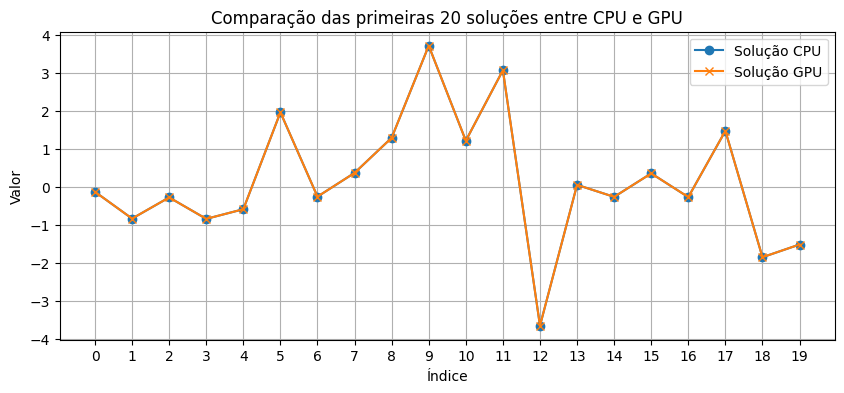

In [ ]:
import numpy as np
import cupy as cp
import scipy.linalg
import time
import matplotlib.pyplot as plt

# Tamanho do sistema, Matriz.
matriz_size = 13000

# 1. Gerar os dados
# Gerando uma matriz A aleatória de MxN e um vetor b de tamanho M
A_cpu = np.random.rand(matriz_size, matriz_size)
b_cpu = np.random.rand(matriz_size)

# 2. Resolver o sistema de equações lineares na CPU usando SciPy
#  Caculando o tempo de execução.
start_time = time.time()
# linalg.solve resolve sistemas lineares no formato Ax = b
x_cpu = scipy.linalg.solve(A_cpu, b_cpu)
cpu_time = time.time() - start_time
print(f"Tempo de execução na CPU com SciPy: {cpu_time:.4f} segundos")

# 3. Transferir os dados para a GPU usando CuPy
A_gpu = cp.array(A_cpu)
b_gpu = cp.array(b_cpu)

# 4. Resolver o sistema de equações lineares na GPU usando CuPy
#  Caculando o tempo de execução.
start_time = time.time()
# linalg.solve resolve sistemas lineares no formato Ax = b
x_gpu = cp.linalg.solve(A_gpu, b_gpu)
cp.cuda.Stream.null.synchronize()
gpu_time = time.time() - start_time
print(f"Tempo de execução na GPU com CuPy: {gpu_time:.4f} segundos")

# 5. Comparar os resultados
# Transferir o resultado de volta para a CPU, para poder comparar.
x_gpu_cpu = cp.asnumpy(x_gpu)

# Verificar se as soluções são aproximadamente iguais
diff = np.max(np.abs(x_cpu - x_gpu_cpu))
print(f"Diferença máxima entre soluções CPU e GPU: {diff:.6e}")

# 6. Visualização dos resultados
# Visualizar os primeiros 20 valores das soluções encontradas para comparação
plt.figure(figsize=(10, 4))
plt.plot(x_cpu[:20], label="Solução CPU", marker='o')
plt.plot(x_gpu_cpu[:20], label="Solução GPU", marker='x')
plt.xticks(range(20))
plt.xlabel("Índice")
plt.ylabel("Valor")
plt.title("Comparação das primeiras 20 soluções entre CPU e GPU")
plt.legend()
plt.grid(True)
plt.show()


#### Exemplo 2 - Transformada de Fourier (FFT) em um sinal.
---
A Transformada de Fourier é amplamente utilizada para transformar sinais do domínio do tempo para o domínio da frequência. Neste exemplo, vamos criar um sinal, aplicar a FFT tanto na CPU (com NumPy e SciPy) quanto na GPU (com CuPy e cuFFT), e então comparar os resultados visualmente e em termos de desempenho.
> Objetivos deste exemplo:
  + Criar um sinal no domínio do tempo a partir de duas ondas senoidais.
  + Aplicar a Transformada de Fourier na CPU usando Numpy e SciPy.
  + Aplicar a Transformada de Fourier na GPU usando Cupy e CuFFT.
  + Comparar os resultados graficamente.
  + Medir o tempo de execução nos dois casos.

In [ ]:
import numpy as np
import cupy as cp
import cupyx.scipy.fft as cufft
import scipy.fft
import time
import matplotlib.pyplot as plt

# 1. Gerar o sinal no domínio do tempo.
# Criamos um sinal composto de duas ondas senoidais de diferentes frequências
def generate_signal(t):
    # Criando as frequências de 5Hz e 20Hz e suas respectivas amplitudes.
    freq1 = 20
    freq2 = 50
    amp1 = 1
    amp2 = 0.5
    # Gerando o sinal.
    signal = (amp1 * np.sin(2 * np.pi * freq1 * t)) + (amp2 * np.sin(2 * np.pi * freq2 * t))
    return signal

In [ ]:
# Parâmetros do sinal
# Frequência de amostragem (Hz), deve ser no mínimo o dobro das frequências do sinal.
Fs = 200
T = 1 / Fs
# Tempo de amostra.
t = np.arange(0, 3, T)
N = len(t)

# Gerar o sinal
signal_cpu = generate_signal(t)

print(f"Amostras por período: {N}")
print(f"Período de amostragem: {T}")

Amostras por período: 600
Período de amostragem: 0.005


In [66]:
# 2. Aplicar a Transformada de Fourier na CPU usando Numpy e SciPy.
# Iniciando contagem do tempo.
start_time = time.time()
# Calculando FFT, retornando a amplitude e fase e sua frequência após a FFT.
fft_cpu = scipy.fft.fft(signal_cpu)
fft_freq_cpu = scipy.fft.fftfreq(N, T)
cpu_time = time.time() - start_time
print(f"Tempo de execução com SciPy (CPU): {cpu_time:.6f} segundos")

Tempo de execução com SciPy (CPU): 0.001273 segundos


In [81]:
# 3. Aplicar a Transformada de Fourier na GPU usando Cupy e CuFFT.
# Transferindo o sinal de CPU para GPU.
signal_gpu = cp.array(signal_cpu)

# Iniciando a contagem do tempo para FFT na GPU (cuFFT).
start_time = time.time()
# Calculando FFT, retornando a amplitude e fase e sua frequência após a FFT.
fft_gpu = cufft.fft(signal_gpu)
fft_freq_gpu = cp.asnumpy(fft_freq_cpu)
cp.cuda.Stream.null.synchronize()  # Sincronizar a GPU para garantir que a operação esteja completa
gpu_time = time.time() - start_time
print(f"Tempo de execução com cuFFT (GPU): {gpu_time:.6f} segundos")

Tempo de execução com cuFFT (GPU): 0.000633 segundos


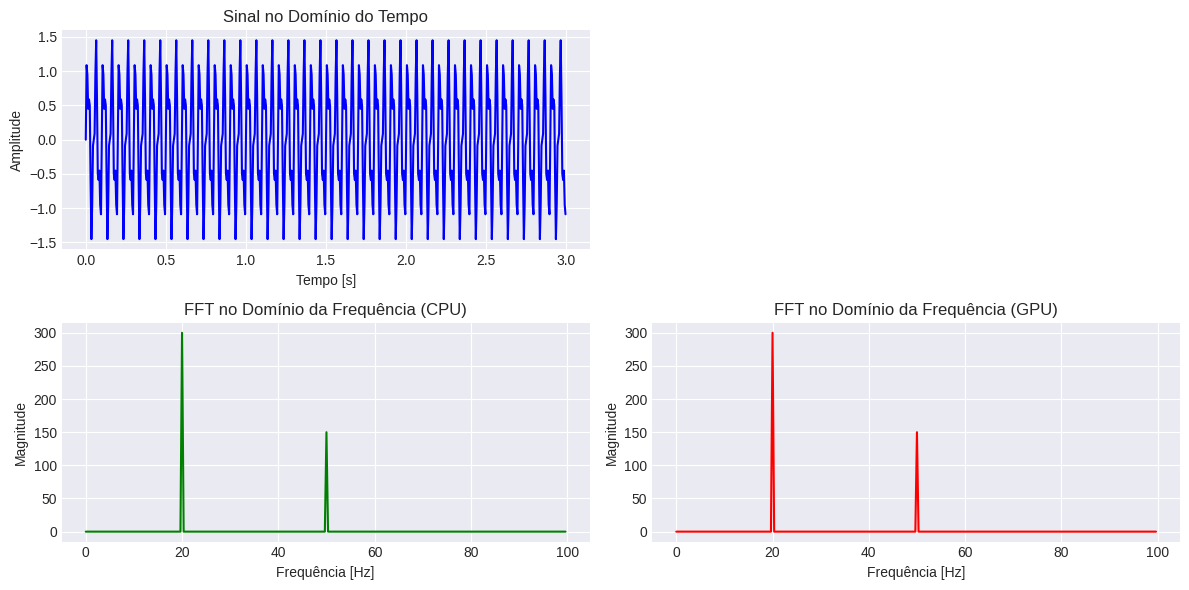

In [82]:
# 4. Comparar os resultados
# Transformar o resultado da GPU de volta para a CPU para comparação
fft_gpu_cpu = cp.asnumpy(fft_gpu)

# 5. Visualizar os resultados usando Matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
fig, axis = plt.subplots(2, 2, figsize=(12, 6))
# Remover o subplot vazio [0, 1] na primeira linha
fig.delaxes(axis[0, 1])

# Sinal no domínio do tempo
axis[0,0].plot(t, signal_cpu, color='b')
axis[0,0].set_title('Sinal no Domínio do Tempo')
axis[0,0].set_xlabel('Tempo [s]')
axis[0,0].set_ylabel('Amplitude')

# FFT no domínio da frequência (CPU)
# Seleciona apenas a metade inicial das frequências, que é a parte util.
axis[1,0].plot(fft_freq_cpu[:N//2], np.abs(fft_cpu[:N//2]), color='g')
axis[1,0].set_title('FFT no Domínio da Frequência (CPU)')
axis[1,0].set_xlabel('Frequência [Hz]')
axis[1,0].set_ylabel('Magnitude')

# FFT no domínio da frequência (GPU)
# Seleciona apenas a metade inicial das frequências, que é a parte util.
axis[1,1].plot(fft_freq_gpu[:N//2], np.abs(fft_gpu_cpu[:N//2]), color='r')
axis[1,1].set_title('FFT no Domínio da Frequência (GPU)')
axis[1,1].set_xlabel('Frequência [Hz]')
axis[1,1].set_ylabel('Magnitude')

plt.tight_layout()
plt.show()